# **1. PROBLEMA**

El presente análisis se realiza sobre una base de datos de ventas de una automotora, que contiene información de 53.727 transacciones con 19 variables asociadas a cada vehículo vendido (marca, modelo, precio, kilometraje, región, tipo de garantía, método de pago, entre otras). El objetivo es aplicar herramientas de analítica descriptiva para caracterizar el perfil de los vehículos y clientes, identificar los factores que influyen en el precio de venta, y generar conclusiones que apoyen la toma de decisiones comerciales de la empresa (por ejemplo, en gestión de stock, pricing y foco geográfico).

## **1.2. Librerías**

In [41]:
# OPERACIONES CON ARREGLOS (MATRICES Y VECTORES)
import numpy as np

# ESTRUCTURA Y MANIPULACIÓN DE DATOS
import pandas as pd

# Desactivar notación científica en pandas
pd.set_option('display.float_format','{:.2f}'.format)

# VISUALIZACIÓN
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import seaborn as sb
# Configura el estilo de seaborn para desactivar la notación científica
sb.set(style="ticks", rc={'axes.formatter.limits': (-2, 10)})
# Grafico de densidad
from seaborn import kdeplot
# Diagrama de caja y bigotes
from seaborn import boxplot

# ADVERTENCIAS
import warnings
warnings.filterwarnings('ignore')

## **1.3. Carga de datos**

In [43]:
df = pd.read_excel("df_automotora_preprocesado_EA.xlsx")



---



# **2. EXPLORACIÓN INICIAL**



---



Visualización del dataset:

In [44]:
#Primeros registros
df.head()

,ID,Fecha_Venta,Ciudad,Region,Marca,Tipo,Modelo,Color,Año_Fabricacion,Kilometraje,Antigüedad,Combustible,Transmision,Equipamiento,Precio_Venta,Metodo_Pago,Tipo_Garantia,Vencimiento_Garantia,Vigencia_Garantia
0,1,2020-01-01,Punta Arenas,Magallanes,Suzuki,SUV,Vitara,Plata,2023,20966.00,2.00,Gasolina,Automática,Básico,15647640,leasing,1 año,2021-01-01,Vencida
1,2,2020-01-01,Coquimbo,Coquimbo,Peugeot,Hatchback,208,Rojo,2021,46558.00,10.00,Diésel,Automática,Medio,6243702,credito,6 meses,2020-07-01,Vencida
2,4,2020-01-01,Talca,Maule,Nissan,Sedán,Versa,Verde,2016,97113.00,9.00,Gasolina,Automática,Básico,5366021,credito,1 año,2021-01-01,Vencida
3,7,2020-01-01,Las Condes,Metropolitana,Suzuki,Sedán,Baleno,Blanco,2014,138689.00,6.00,Gasolina,Automática,Medio,4352676,credito,Sin Garantía,2020-01-01,Vencida
4,8,2020-01-01,Maipú,Metropolitana,Toyota,Sedán,Corolla,Gris,2005,242320.00,15.00,Gasolina,Manual,Básico,2093080,credito,Sin Garantía,2020-01-01,Vencida


In [45]:
#Ultimos registros
df.tail()

,ID,Fecha_Venta,Ciudad,Region,Marca,Tipo,Modelo,Color,Año_Fabricacion,Kilometraje,Antigüedad,Combustible,Transmision,Equipamiento,Precio_Venta,Metodo_Pago,Tipo_Garantia,Vencimiento_Garantia,Vigencia_Garantia
53722,54972,2025-09-30,Viña del Mar,Valparaíso,Peugeot,Sedán,301,Azul,2022,32056.00,3.00,Diésel,Automática,Medio,7096446,credito,6 meses,2026-03-30,Vencida
53723,54975,2025-09-30,Punta Arenas,Magallanes,Hyundai,Sedán,Elantra,Rojo,2002,271017.00,23.00,Gasolina,Manual,Medio,2161932,credito,Sin Garantía,2025-09-30,Vencida
53724,54976,2025-09-30,Chillán,Ñuble,Hyundai,Sedán,Tucson,Blanco,2017,89873.00,8.00,Gasolina,Automática,Medio,6345568,credito,Sin Garantía,2025-09-30,Vencida
53725,54977,2025-09-30,Punta Arenas,Magallanes,Hyundai,Sedán,Santa Fe,Plata,2018,86987.00,7.00,Gasolina,Automática,Medio,6550754,credito,6 meses,2026-03-30,Vencida
53726,54980,2025-09-30,La Unión,Los Ríos,Toyota,Pickup,Corolla,Rojo,2000,294380.00,25.00,Gasolina,Manual,Full,4962858,credito,Sin Garantía,2025-09-30,Vencida


In [46]:
#Muestra aleatoria
df.sample(10)

,ID,Fecha_Venta,Ciudad,Region,Marca,Tipo,Modelo,Color,Año_Fabricacion,Kilometraje,Antigüedad,Combustible,Transmision,Equipamiento,Precio_Venta,Metodo_Pago,Tipo_Garantia,Vencimiento_Garantia,Vigencia_Garantia
32947,33711,2023-07-16,Valparaíso,Valparaíso,Toyota,Pickup,Corolla,Blanco,2015,115612.00,10.00,Diésel,Automática,Medio,9871709,credito,Sin Garantía,2023-07-16,Vencida
40317,41244,2024-04-29,Punta Arenas,Magallanes,Toyota,SUV,Corolla,Beige,2016,97033.00,8.00,Diésel,Automática,Básico,10186471,credito,6 meses,2024-10-29,Vencida
44980,46026,2024-10-28,Las Condes,Metropolitana,Toyota,Sedán,Yaris,Verde,2016,108845.00,8.00,Híbrido,Manual,Básico,4854751,credito,Sin Garantía,2024-10-28,Vencida
42824,43812,2024-08-05,Antofagasta,Antofagasta,Chevrolet,SUV,Tracker,Azul,2016,107750.00,8.00,Diésel,Manual,Full,8616124,credito,Sin Garantía,2024-08-05,Vencida
15322,15663,2021-08-23,Concepción,Biobío,Peugeot,Hatchback,301,Rojo,2015,116732.00,6.00,Gasolina,Manual,Medio,3806729,contado,Sin Garantía,2021-08-23,Vencida
34900,35702,2023-09-30,Punta Arenas,Magallanes,Peugeot,Hatchback,3008,Negro,2024,4431.00,1.00,Gasolina,Manual,Básico,8204336,contado,2 años extendida,2025-09-30,Vencida
30449,31162,2023-04-10,Puerto Montt,Los Lagos,Mazda,Pickup,Mazda3,Beige,2006,229126.00,17.00,Gasolina,Manual,Medio,4965127,credito,Sin Garantía,2023-04-10,Vencida
8303,8485,2020-11-20,Santiago,Biobío,Toyota,SUV,Corolla,Plata,2017,94711.00,8.00,Eléctrico,Manual,Full,10800040,credito,Sin Garantía,2020-11-20,Vencida
41633,42591,2024-06-21,Las Condes,Metropolitana,Toyota,Hatchback,Yaris,Gris,2022,31113.00,2.00,Gasolina,Automática,Medio,6285248,contado,2 años extendida,2026-06-21,Vencida
49347,50489,2025-04-14,Vitacura,Metropolitana,Volkswagen,Sedán,Gol,Plata,2000,295808.00,25.00,Gasolina,Automática,Básico,1481194,credito,Sin Garantía,2025-04-14,Vencida


In [47]:
# Eliminar valores atípicos en 'Año_Fabricacion'
df = df[(df['Año_Fabricacion'] >= 1950) & (df['Año_Fabricacion'] <= 2025)]

Se eliminaron los registros con Año_Fabricacion fuera del rango 1950-2025, por corresponder a valores poco realistas o errores de digitación. Esto redujo la base de 53.727 a 53.701 filas (se descartaron 26 registros), sin afectar de forma relevante el tamaño de la muestra.

## **2.1. Resumen**

Revisamos cuantos registros (filas) y cuántas variables (columnas) tiene el dataset (conjunto de datos):

In [48]:
#Cantidad de filas x cantidad de columnas
df.shape

(53701, 19)

El dataset final queda compuesto por 53.701 filas y 19 columnas, es decir, más de 53 mil ventas registradas, lo que entrega una base robusta para el análisis estadístico.

Revisamos los nombres de las variables, es decir, de cada columna del dataset:

In [49]:
df.columns

Index(['ID', 'Fecha_Venta', 'Ciudad', 'Region', 'Marca', 'Tipo', 'Modelo',
       'Color', 'Año_Fabricacion', 'Kilometraje', 'Antigüedad', 'Combustible',
       'Transmision', 'Equipamiento', 'Precio_Venta', 'Metodo_Pago',
       'Tipo_Garantia', 'Vencimiento_Garantia', 'Vigencia_Garantia'],
      dtype='object')

Las variables cubren tres grandes grupos de información: (1) identificación y ubicación de la venta (ID, fecha, ciudad, región); (2) características del vehículo (marca, tipo, modelo, color, año, kilometraje, antigüedad, combustible, transmisión, equipamiento); y (3) condiciones comerciales (precio de venta, método de pago, garantía).


Inspeccionamos los tipos de variables:

In [50]:
#Tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53701 entries, 0 to 53726
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    53701 non-null  int64         
 1   Fecha_Venta           53701 non-null  datetime64[ns]
 2   Ciudad                53701 non-null  object        
 3   Region                53701 non-null  object        
 4   Marca                 53701 non-null  object        
 5   Tipo                  53701 non-null  object        
 6   Modelo                53701 non-null  object        
 7   Color                 53701 non-null  object        
 8   Año_Fabricacion       53701 non-null  int64         
 9   Kilometraje           53701 non-null  float64       
 10  Antigüedad            53701 non-null  float64       
 11  Combustible           53701 non-null  object        
 12  Transmision           53701 non-null  object        
 13  Equipamiento         

El dataset combina 3 variables numéricas discretas/continuas (Año_Fabricacion, Kilometraje, Precio_Venta, además de Antigüedad), 2 variables de fecha (Fecha_Venta, Vencimiento_Garantia) y 12 variables categóricas (Ciudad, Region, Marca, Tipo, Modelo, Color, Combustible, Transmision, Equipamiento, Metodo_Pago, Tipo_Garantia, Vigencia_Garantia). No se identifican valores nulos en ninguna columna, por lo que no fue necesario un tratamiento de datos faltantes.

Conociendo las clases de las variables categóricas (cualitativas):

In [51]:
#Clases unicas de Vigencia_Garantia
df['Vigencia_Garantia'].unique()

array(['Vencida', 'Vigente'], dtype=object)

In [52]:
#Clases unicas de Tipo_Garantia
df['Tipo_Garantia'].unique()

array(['1 año', '6 meses', 'Sin Garantía', '2 años extendida'],
      dtype=object)

In [53]:
#Clases unicas de Metodo_Pago
df['Metodo_Pago'].unique()

array(['leasing', 'credito', 'contado'], dtype=object)

In [54]:
#Clases unicas de Equipamiento
df['Equipamiento'].unique()

array(['Básico', 'Medio', 'Full'], dtype=object)

In [55]:
#Clases unicas de Transmision
df['Transmision'].unique()

array(['Automática', 'Manual'], dtype=object)

In [56]:
#Clases unicas de Combustible
df['Combustible'].unique()

array(['Gasolina', 'Diésel', 'Híbrido', 'Eléctrico'], dtype=object)

In [57]:
#Clases unicas de Ciudad
df['Ciudad'].unique()

array(['Punta Arenas', 'Coquimbo', 'Talca', 'Las Condes', 'Maipú',
       'Los Ángeles', 'Valparaíso', 'Quillón', 'Temuco', 'Villarrica',
       'Viña del Mar', 'Concepción', 'Osorno', 'Vitacura', 'Puerto Varas',
       'Chillán', 'La Unión', 'La Dehesa', 'Antofagasta', 'Puerto Montt',
       'Providencia', 'Vallenar', 'La Serena', 'Copiapó', 'Pozo Almonte',
       'Calama', 'Rancagua', 'Curicó', 'Iquique', 'San Fernando', 'Arica',
       'Santiago', 'Linares', 'Coyhaique', 'Valdivia'], dtype=object)

In [58]:
#Clases unicas de Region
df['Region'].unique()

array(['Magallanes', 'Coquimbo', 'Maule', 'Metropolitana', 'Biobío',
       'Valparaíso', 'Ñuble', 'Araucanía', 'Los Lagos', 'Los Ríos',
       'Antofagasta', 'Atacama', 'Tarapacá', 'O’Higgins',
       'Arica y Parinacota', 'Aysén', "O'Higgins"], dtype=object)

In [59]:
#Clases unicas de Marca
df['Marca'].unique()

array(['Suzuki', 'Peugeot', 'Nissan', 'Toyota', 'Volkswagen', 'Hyundai',
       'Ford', 'Kia', 'Chevrolet', 'Mazda'], dtype=object)

In [60]:
#Clases unicas de Tipo
df['Tipo'].unique()

array(['SUV', 'Hatchback', 'Sedán', 'Pickup', 'Comercial'], dtype=object)

In [61]:
#Clases unicas de Modelo
df['Modelo'].unique()

array(['Vitara', '208', 'Versa', 'Baleno', 'Corolla', 'Tiguan', 'Tucson',
       'Polo', 'Elantra', 'Fiesta', 'Cerato', 'Sportage', 'Swift', 'Rav4',
       'Yaris', 'Colorado', '2008', 'Sail', 'Santa Fe', 'Vento', '301',
       'CX-5', 'Accent', 'Rio', 'Mazda2', 'Tracker', 'Focus', 'Mazda3',
       'March', 'Sorento', 'Amarok', 'Sentra', '3008', 'Hilux', 'Ranger',
       'Ecosport', 'Seltos', 'X-Trail', 'Partner', 'Prado', 'Gol',
       'Spark', 'i10', 'CX-3', 'Captiva', 'S-Cross', 'Navara', 'Celerio',
       'Escape', 'BT-50'], dtype=object)

Se detectó una inconsistencia en la variable Región, donde "O'Higgins" aparecía escrito con dos tipos de apóstrofe distintos (duplicando la categoría), la cual se corrige más adelante.

Filtros personalizados para descubrir nueva información:

In [62]:
#Conteo de Modelo_Ranger
Modelo_Ranger = df[(df.Modelo == "Ranger")]
Modelo_Ranger

,ID,Fecha_Venta,Ciudad,Region,Marca,Tipo,Modelo,Color,Año_Fabricacion,Kilometraje,Antigüedad,Combustible,Transmision,Equipamiento,Precio_Venta,Metodo_Pago,Tipo_Garantia,Vencimiento_Garantia,Vigencia_Garantia
77,90,2020-01-04,Temuco,Araucanía,Ford,Hatchback,Ranger,Plata,2012,158931.00,8.00,Gasolina,Manual,Básico,2507773,credito,Sin Garantía,2020-01-04,Vencida
276,289,2020-01-11,Coquimbo,Coquimbo,Ford,SUV,Ranger,Plata,2004,247884.00,21.00,Híbrido,Manual,Básico,3399718,leasing,Sin Garantía,2020-01-11,Vencida
312,326,2020-01-12,Temuco,Araucanía,Ford,Pickup,Ranger,Plata,2015,104644.00,5.00,Eléctrico,Automática,Básico,8700661,credito,6 meses,2020-07-12,Vencida
392,407,2020-01-15,Talca,Maule,Ford,Hatchback,Ranger,Plata,2017,95179.00,8.00,Gasolina,Automática,Básico,5134347,credito,Sin Garantía,2020-01-15,Vencida
476,491,2020-01-19,Providencia,Metropolitana,Ford,Hatchback,Ranger,Rojo,2021,53987.00,10.00,Gasolina,Automática,Medio,7515646,credito,1 año,2021-01-19,Vencida
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53371,54615,2025-09-18,Calama,Antofagasta,Ford,Sedán,Ranger,Plata,2019,69952.00,6.00,Gasolina,Automática,Medio,7447666,credito,Sin Garantía,2025-09-18,Vencida
53491,54737,2025-09-22,Los Ángeles,Biobío,Ford,Hatchback,Ranger,Plata,2006,225057.00,19.00,Diésel,Manual,Básico,3220167,credito,6 meses,2026-03-22,Vencida
53542,54788,2025-09-24,La Dehesa,Metropolitana,Ford,Comercial,Ranger,Plata,2009,193275.00,16.00,Gasolina,Manual,Básico,2920658,credito,Sin Garantía,2025-09-24,Vencida
53624,54870,2025-09-26,Punta Arenas,Magallanes,Ford,Sedán,Ranger,Gris,2015,119995.00,10.00,Diésel,Automática,Básico,4715521,credito,6 meses,2026-03-26,Vencida


In [63]:
len(Modelo_Ranger)

583

El modelo Ranger representa solo 583 unidades vendidas, equivalente al 1,09% del total de la base, por lo que es un modelo de baja representatividad dentro del universo de venta de la automotora.

In [64]:
#Cantidad de clientes con compras mayor a 2 millones
compra = df[df['Precio_Venta'] > 2000000]
len(compra)

51005

El 94,98% de las ventas (51.005 de 53.701) supera los $2.000.000, lo que indica que el umbral de 2 millones no es útil para segmentar "compras altas", ya que casi la totalidad del negocio se transa sobre ese monto. Un umbral más alto sería más informativo para distinguir compras premium.

Cálculo de ratios

In [65]:
#Porcentaje de clientes que habitan en la Region Metropolitana
Region = df[(df.Region == "Metropolitana")]
len(Region)/len(df)*100

33.792666803225266

La Región Metropolitana concentra el 33,79% de las ventas totales, siendo por lejos la región con mayor actividad comercial, lo cual es coherente con su mayor densidad poblacional y económica respecto al resto del país.

In [66]:
#Porcentaje de clientes que compran autos Automáticos
auto = df[(df.Transmision == "Automática")]
len(auto)/len(df)*100

52.388223682985426

El 52,39% de los vehículos vendidos cuenta con transmisión automática, levemente por sobre el 47,61% de transmisión manual, lo que sugiere una leve preferencia del mercado hacia vehículos automáticos.

In [67]:
#Cantidad de cliente que compran autos con menos de 10 años de antiguedad
Antigüedad = df[(df.Antigüedad <= 10)]
len(Antigüedad)/len(df)*100

57.056665611441126

El 57,06% de los vehículos vendidos tiene 10 años o menos de antigüedad, lo que indica que más de la mitad del parque comercializado corresponde a vehículos relativamente recientes.

## **2.2. Tablas**

Tablas con valores agregados

In [68]:
# Establecer el formato de punto flotante sin decimales
pd.options.display.float_format = '{:.0f}'.format

In [69]:
# Frecuencia
df['Transmision'].value_counts()

,count
Transmision,
Automática,28133
Manual,25568


Se venden más vehículos automáticos (28.133) que manuales (25.568), confirmando la leve mayoría automática observada en el cálculo de porcentaje anterior.

In [70]:
# Promedio de la Antigüedad por Transmision
df.groupby(['Transmision'])['Antigüedad'].mean() #Agrupar datos por media

,Antigüedad
Transmision,
Automática,9
Manual,11


Los vehículos automáticos tienen una antigüedad promedio de 8,85 años, frente a 11,36 años de los manuales, es decir, los automáticos son en promedio 2,5 años más nuevos. Esto sugiere que la transmisión automática se ha vuelto más común en los modelos recientes.

In [71]:
 # ¿La transmisión automática realmente se paga más caro?
df.groupby('Transmision')['Precio_Venta'].mean()

,Precio_Venta
Transmision,
Automática,6468925
Manual,5202225


Los vehículos automáticos se venden en promedio a $   6.468.925  mientras que los manuales a $  5.202.225, una diferencia de 1.266.700 (cerca de 24% más caro). Esto responde afirmativamente la pregunta planteada, sí, la transmisión automática efectivamente se paga más cara, lo cual es consistente con que también son vehículos más nuevos.

In [72]:
# Función lambda para indicar el formato de moneda
moneda = lambda x: "${:,.0f}".format(x).replace(",", ".")

# Suma del Precio Venta por Marca y Transmision
VAMT = df.groupby(['Marca','Transmision'])['Precio_Venta'].sum().unstack() #Agrupar datos por suma
VAMT = VAMT.applymap(moneda) #Aplicacion del formato moneda
VAMT #mostrar la tabla generada

Transmision,Automática,Manual
Marca,,
Chevrolet,$20.040.160.542,$13.611.246.388
Ford,$11.942.288.646,$9.354.781.956
Hyundai,$25.495.453.265,$19.789.679.641
Kia,$27.214.514.515,$19.602.471.334
Mazda,$10.672.234.144,$6.842.895.522
Nissan,$15.217.106.500,$11.216.650.640
Peugeot,$11.414.072.597,$7.090.540.122
Suzuki,$9.817.147.234,$6.638.035.559
Toyota,$41.233.204.144,$32.408.060.150


Toyota concentra el mayor monto total de ventas del dataset, muy por encima del resto de las marcas, seguida por Chevrolet, Kia e Hyundai. En todas las marcas sin excepción, la transmisión Automática genera mayor monto de ventas que la Manual, lo que confirma que el mercado se inclina claramente hacia vehículos automáticos.

In [73]:
# Configurar opciones para mostrar números sin decimales, en formato de moneda con símbolo $
pd.set_option('display.float_format', lambda x: '{:,.0f}'.format(x).replace(",", "."))

In [74]:
# Tabla dinámica tipo excel
# Promedio de Antigüedad por Marca y Transmision
pd.pivot_table(df, values='Antigüedad', index='Marca', columns='Transmision', aggfunc='mean')

Transmision,Automática,Manual
Marca,,
Chevrolet,8,10
Ford,10,12
Hyundai,9,12
Kia,9,12
Mazda,8,10
Nissan,8,11
Peugeot,6,8
Suzuki,8,11
Toyota,10,12


En todas las marcas, sin excepción, los vehículos con transmisión Manual tienen mayor antigüedad promedio que los Automáticos (brecha de entre 2 y 3 años en casi todos los casos). Esto confirma el patrón que veíamos antes a nivel general, la transmisión automática se asocia a vehículos más nuevos en todo el mercado, no es un efecto puntual de una sola marca.

Peugeot destaca con la menor antigüedad promedio en ambas transmisiones (6 y 8 años), sugiriendo un parque más renovado, mientras que Toyota y Ford presentan los promedios más altos (10 y 12-13 años), lo que indicaría vehículos que permanecen más tiempo en circulación.

# **3. ESTADÍSTICA DESCRIPTIVA**

## **3.1. Frecuencia**

In [75]:
#Frecuencia
df['Transmision'].value_counts()

,count
Transmision,
Automática,28133
Manual,25568


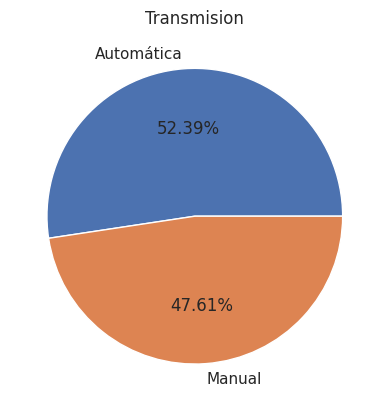

In [76]:
# Grafico de torta
frecuencia_Transmision = df['Transmision'].value_counts() #Cantidad de clientes de cada genero
plt.pie(frecuencia_Transmision, labels=frecuencia_Transmision.index, autopct='%1.2f%%') #Grafico de torta
plt.title("Transmision") #Titulo del grafico
plt.show() #Mostrar grafico

El gráfico confirma la distribución vista anteriormente: aproximadamente 52,4% de los vehículos vendidos son automáticos y 47,6% manuales, una diferencia moderada pero no despreciable a favor de los automáticos.

In [77]:
#Frecuencia
df['Marca'].value_counts()

,count
Marca,
Toyota,13425
Kia,8037
Hyundai,8004
Chevrolet,5283
Nissan,4313
Ford,3751
Mazda,2739
Suzuki,2734
Peugeot,2719


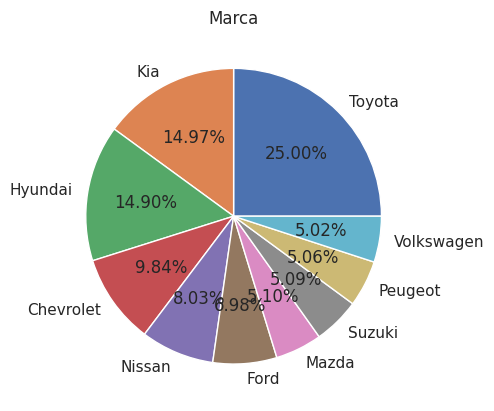

In [78]:
# Grafico de torta
frecuencia_Marca = df['Marca'].value_counts()
plt.pie(frecuencia_Marca, labels=frecuencia_Marca.index, autopct='%1.2f%%')
plt.title("Marca")
plt.show()

Toyota domina claramente las ventas, seguida por Kia e Hyundai, mientras que marcas como Peugeot y Volkswagen representan una participación mucho menor. Esto refleja una alta concentración de la demanda en pocas marcas líderes.

In [79]:
#Frecuencia
df['Marca'].value_counts()

,count
Marca,
Toyota,13425
Kia,8037
Hyundai,8004
Chevrolet,5283
Nissan,4313
Ford,3751
Mazda,2739
Suzuki,2734
Peugeot,2719


Text(0.5, 1.0, 'Marca')

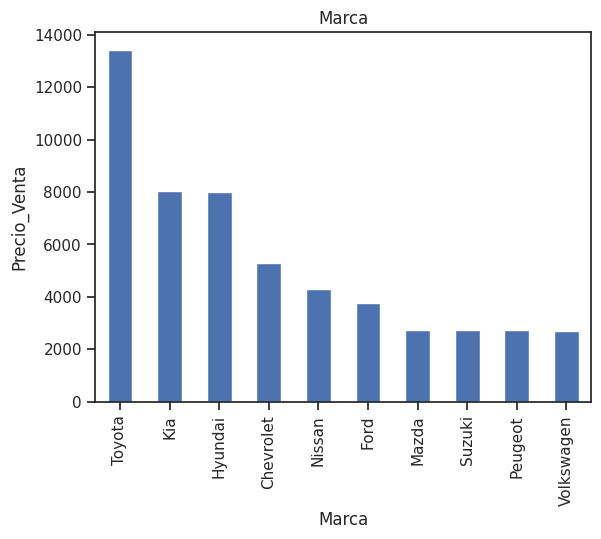

In [80]:
# Grafico de barra
df['Marca'].value_counts().plot.bar() #Grafico de barras
plt.xlabel("Marca")
plt.ylabel("Precio_Venta")
plt.title("Marca")

El gráfico de barras confirma en volumen absoluto lo mismo que el gráfico de torta, Toyota lidera con 13.425 unidades vendidas, muy por sobre Kia (8.037) e Hyundai (8.004), mientras que Peugeot y Volkswagen son las marcas con menor volumen de venta.

In [81]:
#Frecuencia
df['Region'].value_counts()

,count
Region,
Metropolitana,18147
Biobío,4955
Valparaíso,4909
Los Lagos,4330
Magallanes,3117
Araucanía,3067
Coquimbo,2533
Maule,2415
Antofagasta,1782


In [82]:
df['Region'].unique()

array(['Magallanes', 'Coquimbo', 'Maule', 'Metropolitana', 'Biobío',
       'Valparaíso', 'Ñuble', 'Araucanía', 'Los Lagos', 'Los Ríos',
       'Antofagasta', 'Atacama', 'Tarapacá', 'O’Higgins',
       'Arica y Parinacota', 'Aysén', "O'Higgins"], dtype=object)

In [83]:
df['Region'] = df['Region'].replace('O’Higgins', "O'Higgins")

Ahora, verificamos las clases únicas en la columna 'Region' para confirmar que la unificación se realizó correctamente.

In [84]:
df['Region'].unique()

array(['Magallanes', 'Coquimbo', 'Maule', 'Metropolitana', 'Biobío',
       'Valparaíso', 'Ñuble', 'Araucanía', 'Los Lagos', 'Los Ríos',
       'Antofagasta', 'Atacama', 'Tarapacá', "O'Higgins",
       'Arica y Parinacota', 'Aysén'], dtype=object)

Text(0.5, 1.0, 'Region')

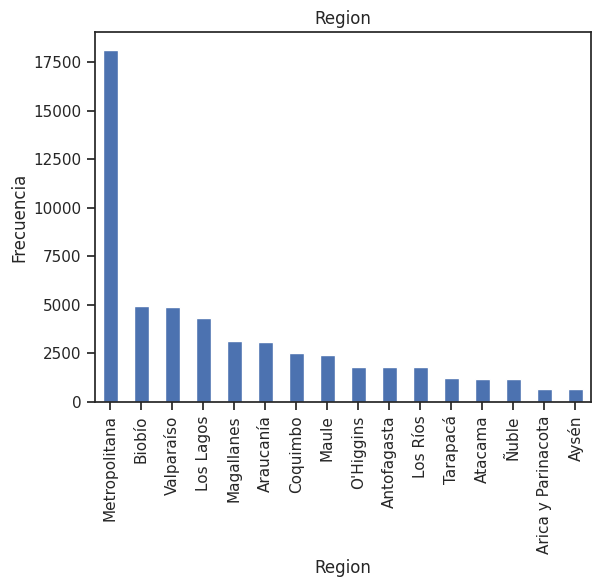

In [85]:
# Grafico de barra
df['Region'].value_counts().plot.bar()
plt.xlabel("Region")
plt.ylabel("Frecuencia")
plt.title("Region")


In [86]:
# Frecuencia
df['Region'].value_counts()

,count
Region,
Metropolitana,18147
Biobío,4955
Valparaíso,4909
Los Lagos,4330
Magallanes,3117
Araucanía,3067
Coquimbo,2533
Maule,2415
O'Higgins,1809


Text(0.5, 1.0, 'Región')

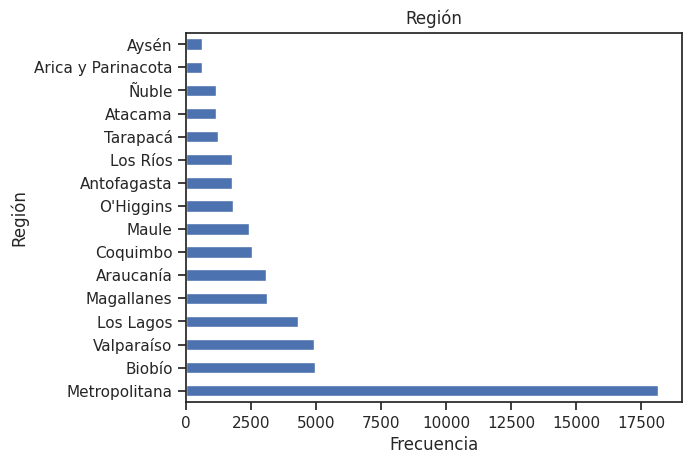

In [87]:
# Grafico de barras horizontales
df['Region'].value_counts().plot.barh()#Gráfico de barras horizontal
plt.xlabel("Frecuencia")
plt.ylabel("Región")
plt.title("Región")

La Región Metropolitana concentra la mayor cantidad de ventas (cerca de 18.000), casi cuadruplicando a la segunda región (Biobío, app 5.000). Le siguen Valparaíso y Los Lagos con volúmenes intermedios-altos. En el extremo opuesto, Aysén y Arica y Parinacota registran la menor actividad comercial, junto con Ñuble, Atacama y Tarapacá. Este patrón refleja la fuerte concentración demográfica y económica del país en la zona central, especialmente en la Región Metropolitana, mientras que las regiones extremas (norte y sur) presentan mercados mucho más acotados.

## **3.2. Medidas de Tendencia Central**

In [88]:
# Establecer el formato de punto flotante a 2 decimales
pd.options.display.float_format = '{:.2f}'.format

In [89]:
#Moda de todas las variables
df.mode().iloc[0]

,0
ID,1
Fecha_Venta,2023-09-10 00:00:00
Ciudad,Punta Arenas
Region,Metropolitana
Marca,Toyota
Tipo,Sedán
Modelo,Corolla
Color,Negro
Año_Fabricacion,2019.00
Kilometraje,96278.00


In [90]:
#Resumen estadistico
df.describe()

,ID,Fecha_Venta,Año_Fabricacion,Kilometraje,Antigüedad,Precio_Venta,Vencimiento_Garantia
count,53701.00,53701,53701.00,53701.00,53701.00,53701.00,53701
mean,27472.86,2022-11-17 18:14:53.346492416,2014.41,127039.05,10.04,5865826.33,2023-04-19 02:02:26.276605696
min,1.00,2020-01-01 00:00:00,2000.00,55.00,1.00,1000000.00,2020-01-01 00:00:00
25%,13724.00,2021-06-10 00:00:00,2010.00,65891.00,5.00,3269087.00,2021-11-04 00:00:00
50%,27469.00,2022-11-20 00:00:00,2015.00,121964.00,10.00,5288244.00,2023-04-20 00:00:00
75%,41209.00,2024-04-27 00:00:00,2020.00,183436.00,14.00,7742105.00,2024-09-28 00:00:00
max,54980.00,2025-09-30 00:00:00,2024.00,315760.00,25.00,15753702.00,2027-09-29 00:00:00
std,15865.40,NaN,6.08,73108.20,5.83,3165609.91,NaN


In [91]:
# Filtra solo las columnas numéricas y excluye la columna 'ID'
columnas_numericas = df.select_dtypes(include=['number']).drop(columns=['ID'])
columnas_numericas.head()

,Año_Fabricacion,Kilometraje,Antigüedad,Precio_Venta
0,2023,20966.00,2.00,15647640
1,2021,46558.00,10.00,6243702
2,2016,97113.00,9.00,5366021
3,2014,138689.00,6.00,4352676
4,2005,242320.00,15.00,2093080


In [92]:
columnas_numericas.mode().iloc[0]

,0
Año_Fabricacion,2019.00
Kilometraje,96278.00
Antigüedad,5.00
Precio_Venta,1000000.00


In [93]:
#Mediana de variables numericas
columnas_numericas.median()

,0
Año_Fabricacion,2015.00
Kilometraje,121964.00
Antigüedad,10.00
Precio_Venta,5288244.00


In [94]:
#Media de variables numericas
columnas_numericas.mean()

,0
Año_Fabricacion,2014.41
Kilometraje,127039.05
Antigüedad,10.04
Precio_Venta,5865826.33


## **3.3. Distribución**

▶ Asimetría

coeficiente = 0 ➞ simétrica

coeficiente > 0 ➞ asimétrica positiva

coeficiente < 0 ➞ asimétrica negativa

In [95]:
from scipy.stats import skew

In [96]:
skew(df['Precio_Venta'])

np.float64(0.8913060832114471)

In [97]:
# Calcula la asimetría para cada columna numérica
for columna in columnas_numericas:
    asimetria = skew(df[columna])
    print(f"Asimetría de Pearson para '{columna}': {asimetria}")

Asimetría de Pearson para 'Año_Fabricacion': -0.2707839576144257
Asimetría de Pearson para 'Kilometraje': 0.2694591721640357
Asimetría de Pearson para 'Antigüedad': 0.34053958309192506
Asimetría de Pearson para 'Precio_Venta': 0.8913060832114471


Precio_Venta presenta la asimetría más marcada de todas las variables (0,89), de tipo positiva, lo que confirma que hay una cola de ventas de alto valor que sesga la distribución hacia la derecha. Kilometraje (0,27) y Antigüedad (0,34) muestran asimetría positiva leve, mientras que Año_Fabricacion (-0,27) presenta una asimetría negativa leve, es decir, hay una concentración algo mayor de vehículos con años de fabricación más recientes.

▶ Curtosis

coeficiente > 0 ➞ leptocúrtica

coeficiente = 0 ➞ mesocúrtica

coeficiente < 0 ➞ platicúrtica

In [98]:
from scipy.stats import kurtosis

In [99]:
kurtosis(df['Precio_Venta'])

np.float64(0.37643639078655955)

In [100]:
# Calcula la curtosis de Fisher para cada columna numérica
for columna in columnas_numericas:
    curtosis = kurtosis(df[columna])
    print(f"Curtosis de Fisher para '{columna}': {curtosis}")

Curtosis de Fisher para 'Año_Fabricacion': -0.8638106663174598
Curtosis de Fisher para 'Kilometraje': -0.8552906191249763
Curtosis de Fisher para 'Antigüedad': -0.7089508987528226
Curtosis de Fisher para 'Precio_Venta': 0.37643639078655955


Año_Fabricacion, Kilometraje y Antigüedad son platicúrticas (curtosis negativa, entre -0,71 y -0,86), lo que indica distribuciones más "aplanadas" que la normal, con datos más dispersos y colas menos pronunciadas. Precio_Venta, en cambio, tiene una curtosis levemente positiva (0,38), cercana a una distribución mesocúrtica, sin colas ni concentración extremas.

▶ Función de densidad

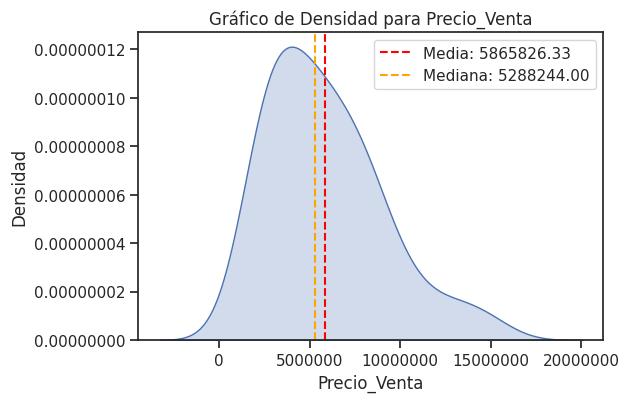

In [101]:
# Gráfico de densidad
plt.figure(figsize=(6, 4))
sb.kdeplot(df['Precio_Venta'], shade=True, bw_adjust=4)
plt.axvline(df['Precio_Venta'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df['Precio_Venta'].mean():.2f}')
plt.axvline(df['Precio_Venta'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df['Precio_Venta'].median():.2f}')
plt.ticklabel_format(useOffset=False, style='plain')  # Quitar notación científica
plt.legend()
plt.xlabel("Precio_Venta")
plt.ylabel("Densidad")
plt.title("Gráfico de Densidad para Precio_Venta")
plt.show()

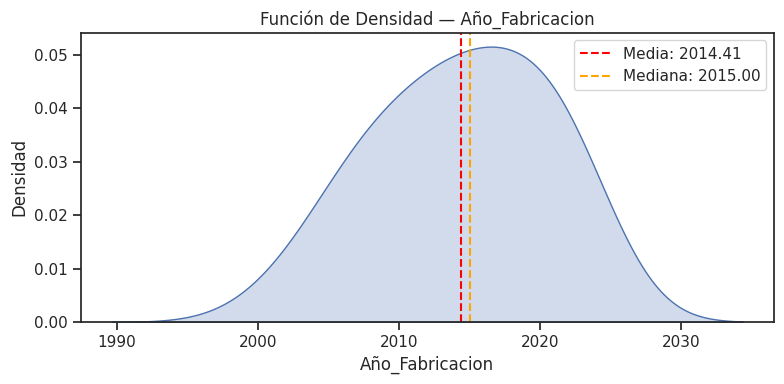

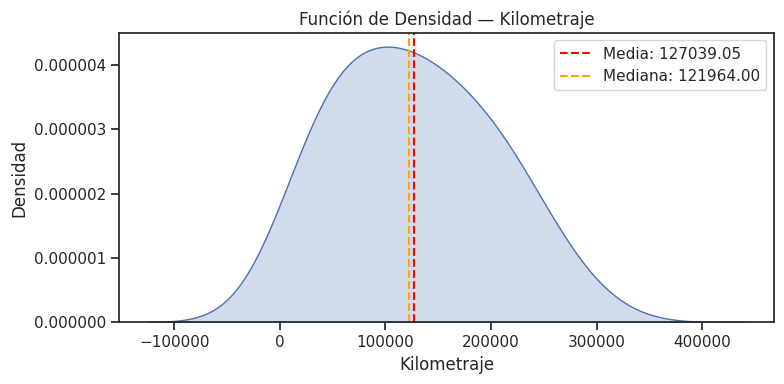

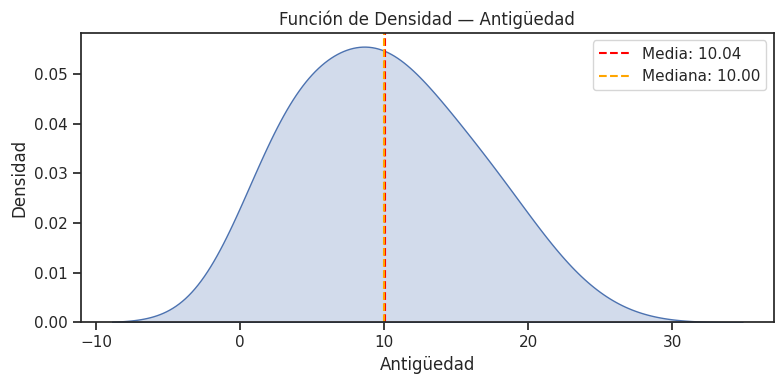

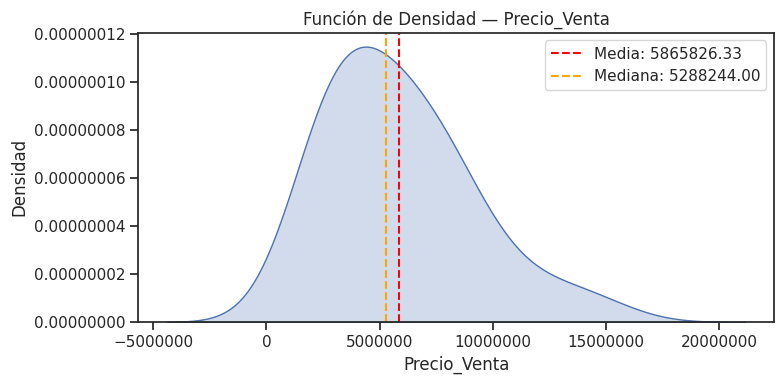

In [102]:
# Itera a través de las columnas numéricas y crea gráficos de densidad
for column in columnas_numericas.columns:
    plt.figure(figsize=(8, 4))
    sb.kdeplot(df[column].dropna(), fill=True, bw_adjust=5)
    plt.axvline(df[column].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df[column].mean():.2f}')
    plt.axvline(df[column].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {df[column].median():.2f}')
    plt.ticklabel_format(useOffset=False, style='plain')  # Quitar notación científica
    plt.title(f'Función de Densidad — {column}')
    plt.xlabel(column)
    plt.ylabel('Densidad')
    plt.legend()
    plt.tight_layout()
    plt.show()

La curva de densidad de Precio_Venta muestra una distribución  con una cola más larga hacia la derecha, consistente con la asimetría positiva calculada previamente, la mayoría de las ventas se concentra en un rango medio, pero existen ventas puntuales de alto valor que extienden la cola. Las variables Kilometraje, Antigüedad y Año_Fabricacion muestran distribuciones más planas y sin colas marcadas, coherente con su curtosis negativa.

▶ Histograma

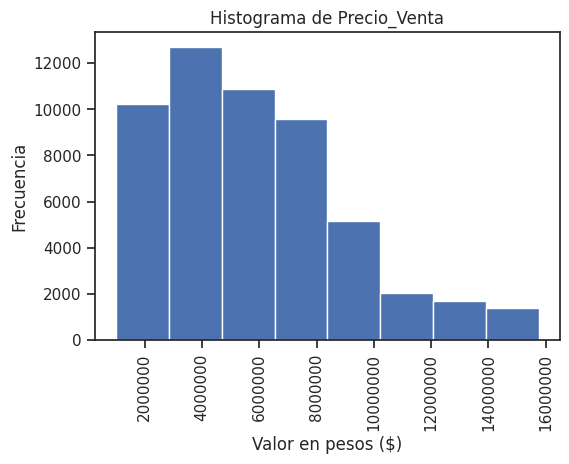

In [103]:
# Histograma
plt.figure(figsize=(6,4))
plt.hist(df['Precio_Venta'], bins=8) # bins es el numero de barras
plt.xlabel("Valor en pesos ($)")
plt.ylabel("Frecuencia")
plt.title("Histograma de Precio_Venta")
plt.xticks(rotation=90)
plt.show()

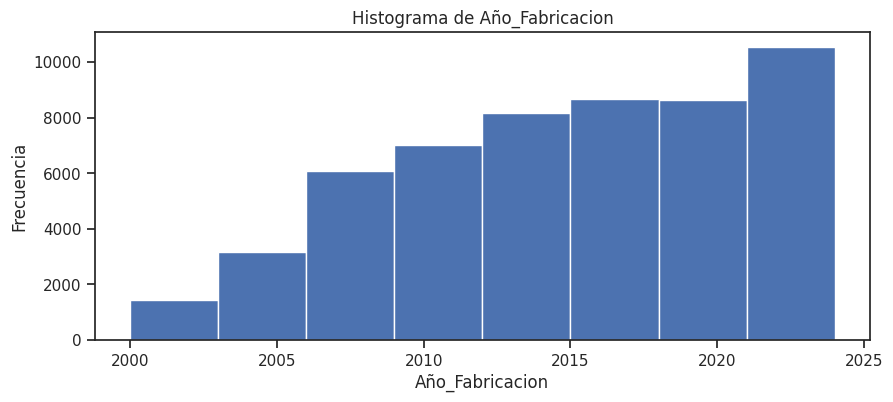

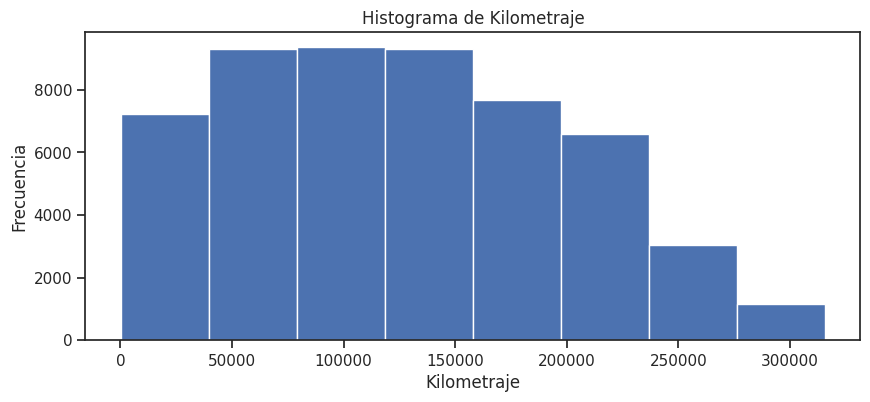

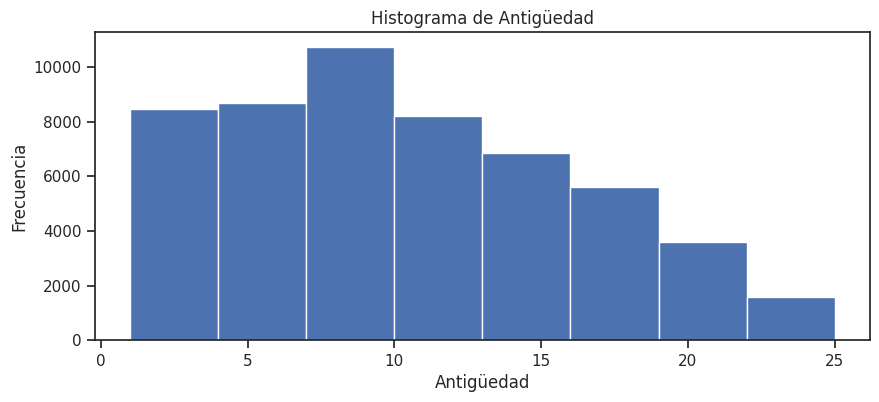

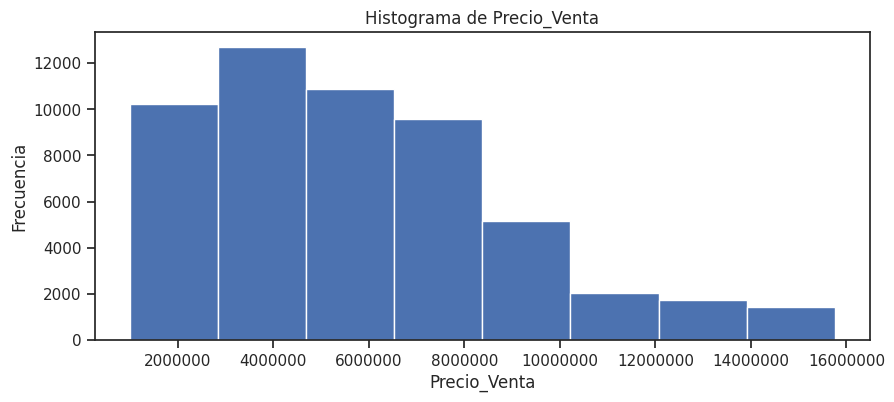

In [104]:
# Itera a través de las columnas numéricas y crea histogramas
for column in columnas_numericas.columns:
    plt.figure(figsize=(10, 4))  # Tamaño del gráfico
    plt.hist(x=df[column], bins=8)  # Gráfico de histograma
    plt.xlabel(column)  # Título del eje x con el nombre de la columna
    plt.ylabel("Frecuencia")  # Título del eje Y
    plt.title(f"Histograma de {column}")  # Título del gráfico
    plt.show()  # Mostrar el gráfico

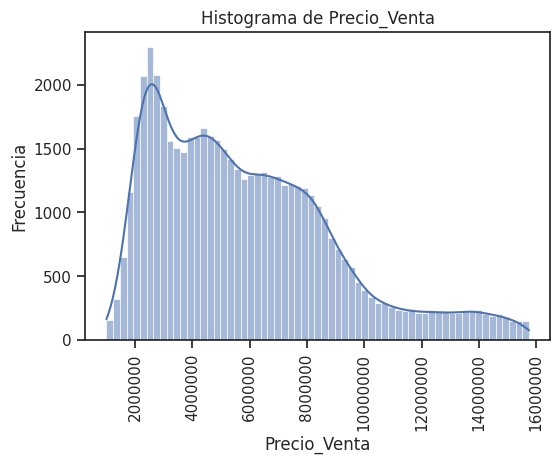

In [105]:
# Histogramas + funcion de densidad
plt.figure(figsize=(6, 4))
sb.histplot(df['Precio_Venta'],kde=True)
plt.ticklabel_format(useOffset=False, style='plain' )  # Quitar notación científica
plt.xlabel('Precio_Venta')
plt.ylabel("Frecuencia")
plt.title(f"Histograma de Precio_Venta")
plt.xticks(rotation=90)
plt.show()

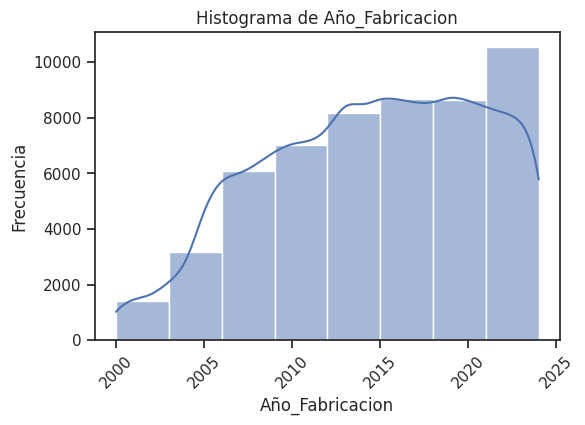

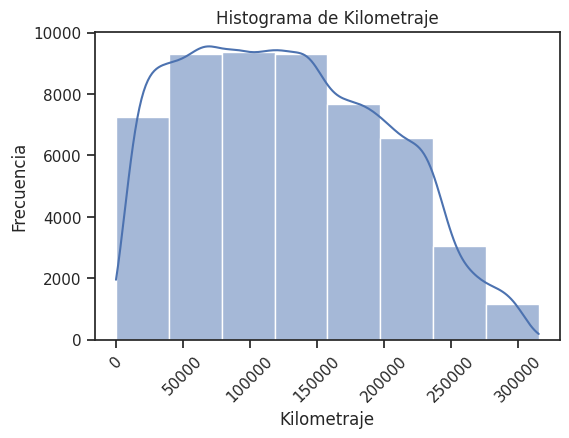

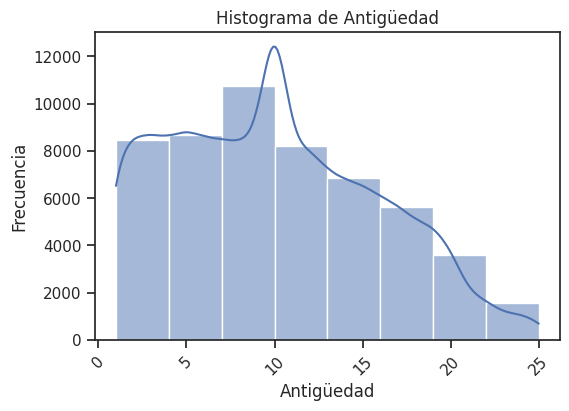

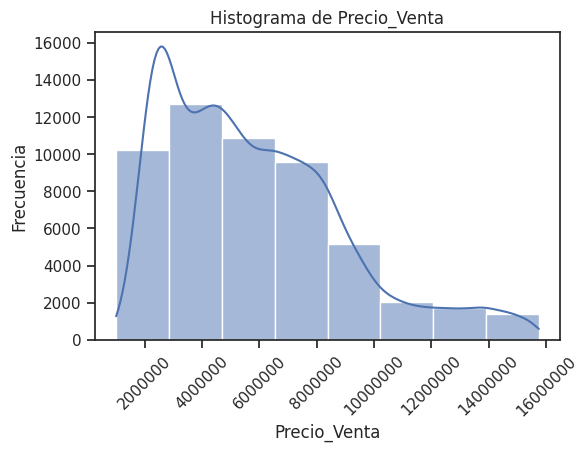

In [106]:
# Itera a través de las columnas numéricas y crea histogramas + funcion de densidad
for column in columnas_numericas.columns:
    plt.figure(figsize=(6, 4))  # Tamaño del gráfico
    sb.histplot(x=df[column],kde=True, bins=8)  # Gráfico de histograma + KDE
    plt.ticklabel_format(useOffset=False, style='plain')  # Quitar notación científica
    plt.xticks(rotation=45) # Rotar etiquetas del eje X
    plt.xlabel(column)  # Título del eje x con el nombre de la columna
    plt.ylabel("Frecuencia")  # Título del eje Y
    plt.title(f"Histograma de {column}")  # Título del gráfico
    plt.show()  # Mostrar el gráfico

El histograma de Precio_Venta confirma visualmente la concentración de ventas en el tramo medio-bajo, con una menor cantidad de vehículos en los tramos de precio más alto (asimetría a la derecha). Los histogramas de Kilometraje y Antigüedad muestran una distribución más repartida entre sus rangos, sin una concentración tan marcada en un solo tramo.

## **3.4. Medidas de Dispersión**

In [107]:
#Varianza
columnas_numericas.var()

,0
Año_Fabricacion,36.97
Kilometraje,5344809316.88
Antigüedad,33.94
Precio_Venta,10021086073947.56


In [108]:
#Desviación Estandar
columnas_numericas.std()

,0
Año_Fabricacion,6.08
Kilometraje,73108.20
Antigüedad,5.83
Precio_Venta,3165609.91


In [109]:
columnas_numericas.mean()

,0
Año_Fabricacion,2014.41
Kilometraje,127039.05
Antigüedad,10.04
Precio_Venta,5865826.33


Precio_Venta y Kilometraje son las variables con mayor variabilidad absoluta, lo cual es esperable dada la escala de sus unidades (pesos y kilómetros). Para comparar la dispersión de forma más justa entre variables de distinta escala, se calcula a continuación el coeficiente de variación.

▶ Coeficiente de variación

coeficiente = 50 ➞ dispersión moderada

coeficiente > 50 ➞ alta dispersión

coeficiente < 50 ➞ baja dispersión

In [110]:
std_Precio_Venta = df['Precio_Venta'].std()
mean_Precio_Venta = df['Precio_Venta'].mean()

# Coeficiente de variación
cv_Precio_Venta = std_Precio_Venta/mean_Precio_Venta*100
print(cv_Precio_Venta)

53.966989939779275


In [111]:
std_año_fabricación = df['Año_Fabricacion'].std()
mean_año_fabricacion = df['Año_Fabricacion'].mean()

# Coeficiente de variación
cv_año_fabricación = std_año_fabricación/mean_año_fabricacion*100
print(cv_año_fabricación)

0.301844884629219


In [112]:
std_kilometraje = df['Kilometraje'].std()
mean_kilometraje = df['Kilometraje'].mean()

# Coeficiente de variación
cv_kilometraje = std_kilometraje/mean_kilometraje*100
print(cv_kilometraje)

57.54782004785357


In [113]:
std_antiguedad= df['Antigüedad'].std()
mean_antiguedad = df['Antigüedad'].mean()

# Coeficiente de variación
cv_antiguedad = std_antiguedad/mean_antiguedad*100
print(cv_antiguedad)

58.00511113281982


Precio_Venta (CV=53,97%), Kilometraje (CV=57,55%) y Antigüedad (CV=58,01%) presentan todas alta dispersión según la regla establecida (CV>50), lo que indica que los vehículos vendidos son muy heterogéneos en precio, uso y edad. En contraste, Año_Fabricacion tiene una dispersión prácticamente nula (CV=0,30%), ya que todos los valores están acotados a un rango de años relativamente estrecho.

## **3.5. Medidas de Posición**

In [114]:
# Las medidas de posicion son los cuartiles (4 partes iguales)
# Q1 = 25%
# Q2 = 50% (mediana)
# Q3 = 75%
df.describe()

,ID,Fecha_Venta,Año_Fabricacion,Kilometraje,Antigüedad,Precio_Venta,Vencimiento_Garantia
count,53701.00,53701,53701.00,53701.00,53701.00,53701.00,53701
mean,27472.86,2022-11-17 18:14:53.346492416,2014.41,127039.05,10.04,5865826.33,2023-04-19 02:02:26.276605696
min,1.00,2020-01-01 00:00:00,2000.00,55.00,1.00,1000000.00,2020-01-01 00:00:00
25%,13724.00,2021-06-10 00:00:00,2010.00,65891.00,5.00,3269087.00,2021-11-04 00:00:00
50%,27469.00,2022-11-20 00:00:00,2015.00,121964.00,10.00,5288244.00,2023-04-20 00:00:00
75%,41209.00,2024-04-27 00:00:00,2020.00,183436.00,14.00,7742105.00,2024-09-28 00:00:00
max,54980.00,2025-09-30 00:00:00,2024.00,315760.00,25.00,15753702.00,2027-09-29 00:00:00
std,15865.40,NaN,6.08,73108.20,5.83,3165609.91,NaN


In [115]:
from scipy.stats import iqr
# Rango intercuartil
print("IQR Precio Venta:", iqr(df['Precio_Venta']))
print("IQR Año Fabraicación:", iqr(df['Año_Fabricacion']))
print("IQR Antiguedad:", iqr(df['Antigüedad']))
print("IQR Kilometraje:", iqr(df['Kilometraje']))

IQR Precio Venta: 4473018.0
IQR Año Fabraicación: 10.0
IQR Antiguedad: 9.0
IQR Kilometraje: 117545.0


El rango intercuartílico de Precio_Venta es de $4.473.018, es decir, el 50% central de las ventas se mueve en un rango de precio bastante amplio, coherente con la alta dispersión detectada por el coeficiente de variación. Antigüedad (IQR=9 años) y Año_Fabricacion (IQR=10 años) también muestran rangos centrales amplios, reflejando un parque de vehículos heterogéneo en edad.

▶ Diagrama de caja y bigotes (boxplot)

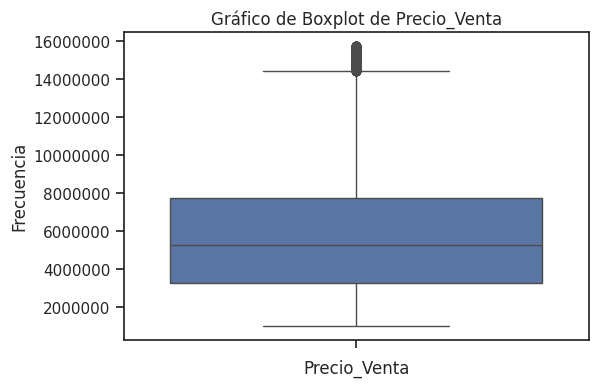

In [116]:
#Boxplot
plt.figure(figsize=(6, 4))  # Tamaño del gráfico
boxplot(df['Precio_Venta'])  # Gráfico de boxplot
plt.xlabel("Precio_Venta")  # Título del eje x con el nombre de la columna
plt.ylabel("Frecuencia")  # Título del eje Y
plt.title(f"Gráfico de Boxplot de Precio_Venta")  # Título del gráfico
plt.show()  # Mostrar el gráfico

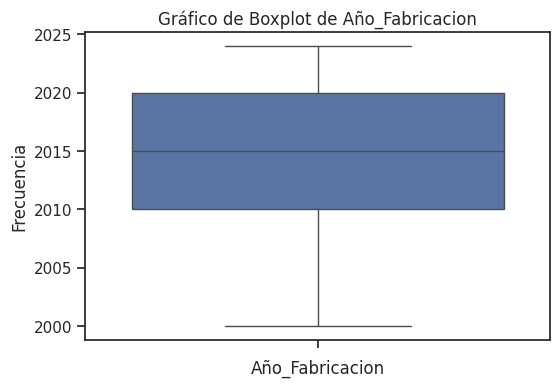

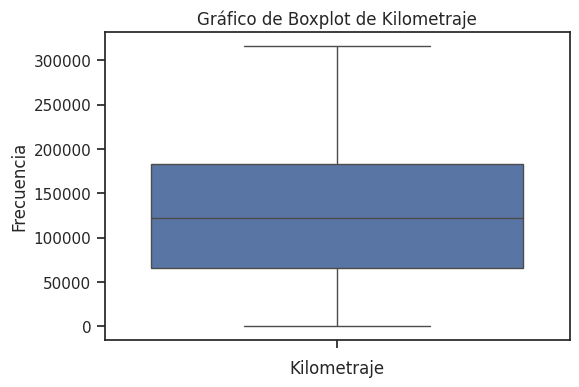

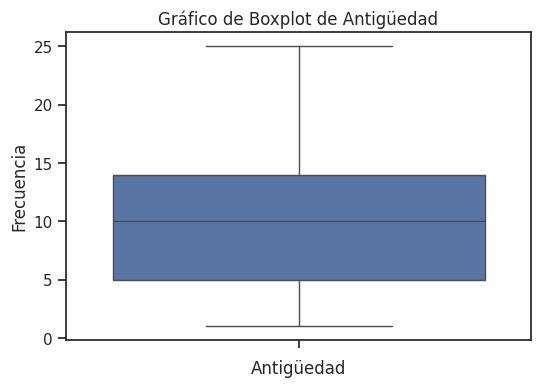

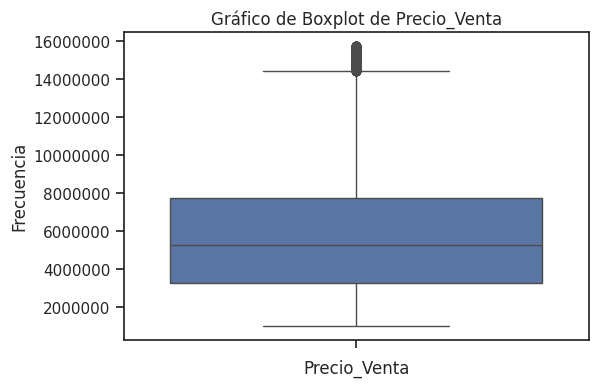

In [117]:
# Itera a través de las columnas numéricas y crea gráficos de boxplot
for column in columnas_numericas.columns:
    plt.figure(figsize=(6, 4))  # Tamaño del gráfico
    boxplot(df[column])  # Gráfico de boxplot
    plt.xlabel(column)  # Título del eje x con el nombre de la columna
    plt.ylabel("Frecuencia")  # Título del eje Y
    plt.title(f"Gráfico de Boxplot de {column}")  # Título del gráfico
    plt.show()  # Mostrar el gráfico

El boxplot de Precio_Venta muestra la presencia de valores atípicos (outliers) en el extremo superior, correspondientes a ventas de alto valor, consistente con la asimetría positiva observada anteriormente. Kilometraje y Antigüedad presentan una dispersión más regular, sin outliers tan marcados.

Text(0.5, 1.0, 'Precio_Venta por Transmision')

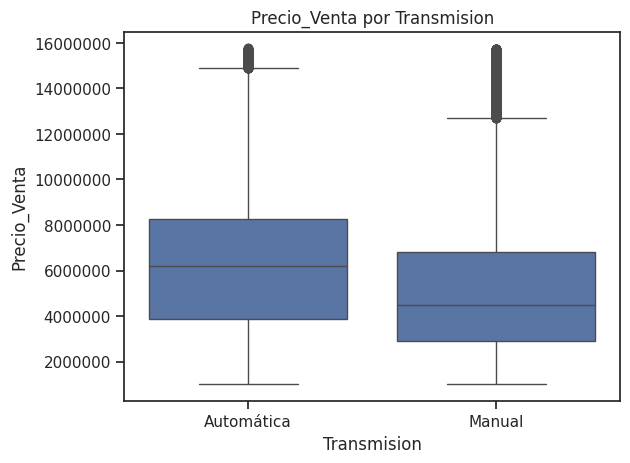

In [118]:
boxplot(x="Transmision", y="Precio_Venta", data=df) #Diagrama de caja y bigotes
plt.xlabel("Transmision") #Titulo de eje x
plt.ylabel("Precio_Venta") #Titulo de eje y
plt.title("Precio_Venta por Transmision") #Titulo del grafico

El boxplot confirma que los vehículos automáticos tienen una mediana de precio ($6.206.277) claramente superior a la de los manuales ($4.492.239), con cajas que apenas se solapan, lo que refuerza que la transmisión automática es un factor asociado a mayor valor de venta.

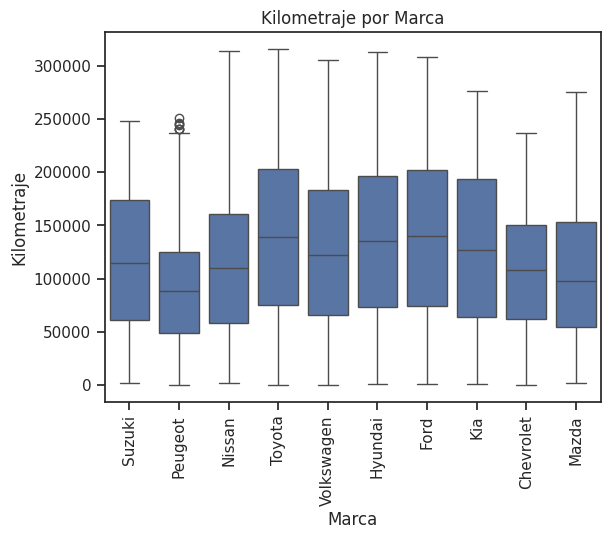

In [119]:
boxplot(x="Marca", y="Kilometraje", data=df) #Diagrama de caja y bigotes
plt.xlabel("Marca") #Titulo de eje x
plt.ylabel("Kilometraje") #Titulo de eje y
plt.title("Kilometraje por Marca") #Titulo del grafico
plt.xticks(rotation=90)
plt.show()

Peugeot presenta el kilometraje mediano más bajo (88.018 km), mientras que Ford presenta el más alto (140.255 km), lo que sugiere que los vehículos Ford vendidos tienden a tener mayor uso previo que los de otras marcas.

Text(0.5, 1.0, 'Precio_Venta por Color')

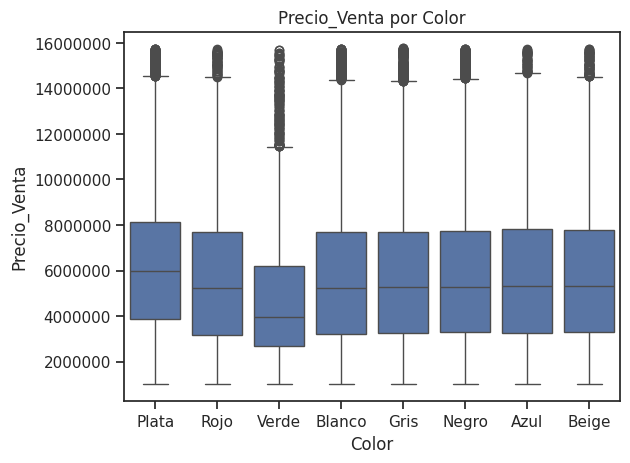

In [120]:
boxplot(x="Color", y="Precio_Venta", data=df)
plt.xlabel("Color")
plt.ylabel("Precio_Venta")
plt.title("Precio_Venta por Color")

El color Verde destaca con una mediana de precio notoriamente más baja ($3.980.454) que el resto de los colores,  mientras que Plata presenta la mediana más alta ($5.990.183). Esto podría indicar que ciertos colores se asocian a modelos o gamas específicas dentro del catálogo.

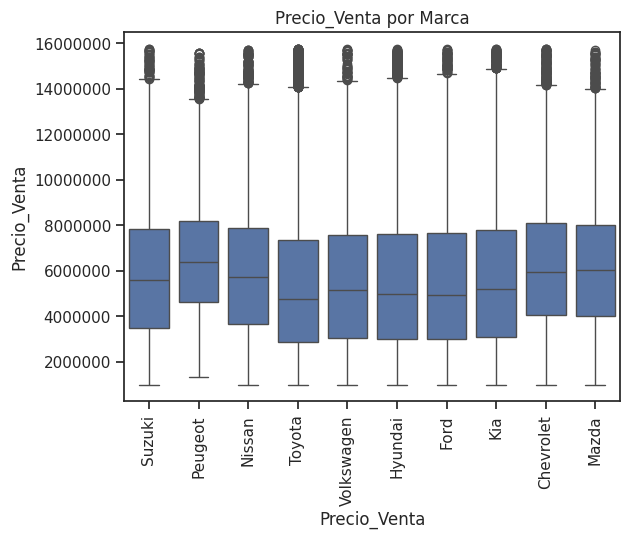

In [121]:
boxplot(x="Marca", y="Precio_Venta", data=df)
plt.xlabel("Precio_Venta")
plt.ylabel("Precio_Venta")
plt.title("Precio_Venta por Marca")
plt.xticks(rotation=90)
plt.show()

Pese a ser la marca más vendida, Toyota presenta la mediana de precio más baja ($4.773.864), lo que sugiere una estrategia de volumen con vehículos más accesibles. En el otro extremo, Peugeot, con bajo volumen de ventas, tiene la mediana de precio más alta ($6.384.886), posicionándose como una marca de nicho más premium.

Text(0.5, 1.0, 'Precio_Venta por Región')

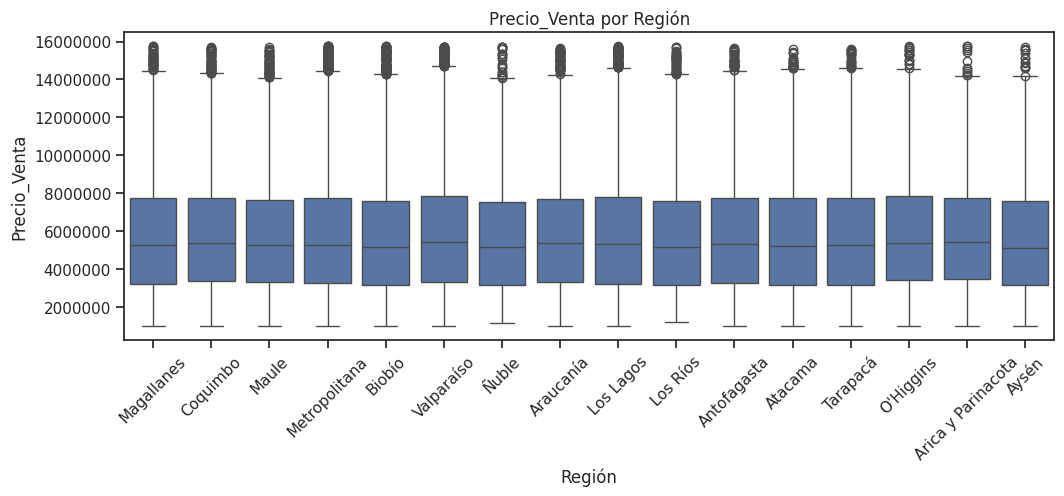

In [122]:
plt.figure(figsize=(12, 4))
boxplot(x="Region", y="Precio_Venta", data=df)
plt.xticks(rotation=45) #rotar etiquetas del eje X
plt.xlabel("Región")
plt.ylabel("Precio_Venta")
plt.title("Precio_Venta por Región")

Las medianas de precio por región son relativamente parejas, entre $5.144.132 (Aysén) y $5.436.713 (Valparaíso), sin una región que se distancie fuertemente del resto. Esto indica que el precio de venta no varía mucho según la ubicación geográfica, a diferencia del volumen de ventas, que sí está muy concentrado en la Región Metropolitana.

## **3.6. Correlación**

▶ Coeficiente de correlación de Pearson

coeficiente = 0 ➞ no hay relación

coeficiente > 0 ➞ relación directa

coeficiente < 0 ➞ relación inversa

In [123]:
#Correlacion de todas las variables con Precio_Venta
r = columnas_numericas.corr()
r["Precio_Venta"].sort_values(ascending=False)

,Precio_Venta
Precio_Venta,1.00
Año_Fabricacion,0.76
Antigüedad,-0.70
Kilometraje,-0.76


Año_Fabricacion presenta la correlación más fuerte con Precio_Venta (r=0,76, relación directa): a mayor año de fabricación (vehículo más nuevo), mayor precio. Kilometraje (r=-0,76) y Antigüedad (r=-0,70) muestran correlaciones inversas de magnitud similar, confirmando que a mayor uso o edad del vehículo, menor es su precio de venta.

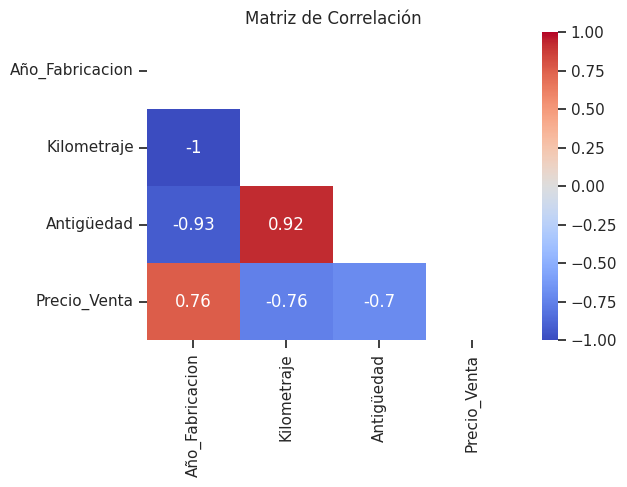

In [124]:
#Matriz de correlacion
corr = columnas_numericas.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(6,4))
sb.heatmap(corr, cmap="coolwarm",annot=True, vmax=1, vmin=-1, center=0, mask=mask)
plt.title("Matriz de Correlación")
plt.show()

El mapa de calor evidencia que las tres variables numéricas (Año_Fabricacion, Kilometraje y Antigüedad) están fuertemente correlacionadas entre sí y con Precio_Venta, lo cual es esperable dado que están directamente relacionadas con el ciclo de vida del vehículo. Esto confirma que la antigüedad y el uso son los principales factores numéricos que explican el precio de venta.

▶ Diagrama de Dispersión

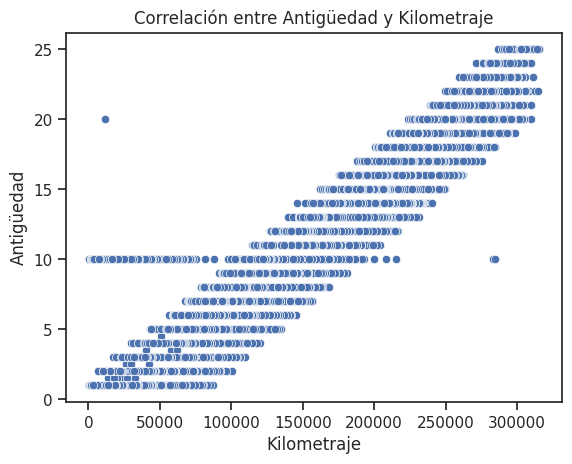

In [128]:
#Diagrama de dispersion
sb.scatterplot(
    x=df. Kilometraje,
    y=df. Antigüedad,
    data=df)
plt.xticks(rotation=0) #rotar etiquetas del eje X
plt.title("Correlación entre Antigüedad y Kilometraje")
plt.show()

El gráfico de dispersión muestra una tendencia claramente creciente entre ambas variables: a mayor antigüedad del vehículo, mayor es su kilometraje acumulado, lo cual es un resultado esperable y valida la coherencia interna del dataset.

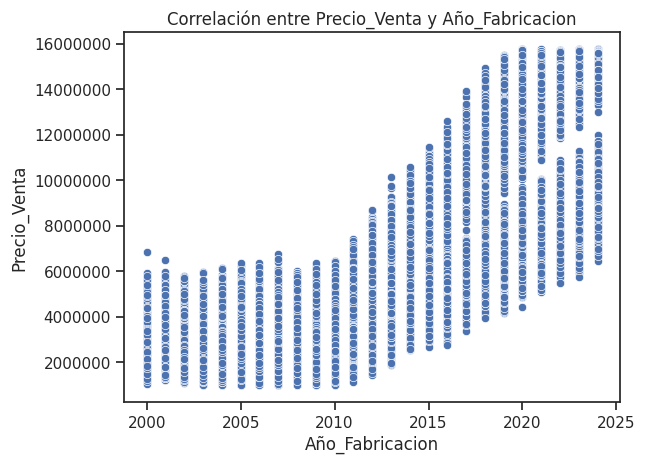

In [127]:
#Diagrama de dispersion
sb.scatterplot(
    x=df. Año_Fabricacion,
    y=df. Precio_Venta,
    data=df)
plt.xticks(rotation=0) #rotar etiquetas del eje X
plt.title("Correlación entre Precio_Venta y Año_Fabricacion")
plt.show()

Se observa una tendencia ascendente: los vehículos con año de fabricación más reciente tienden a venderse a precios más altos, confirmando la fuerte correlación positiva (r=0,76) calculada anteriormente.

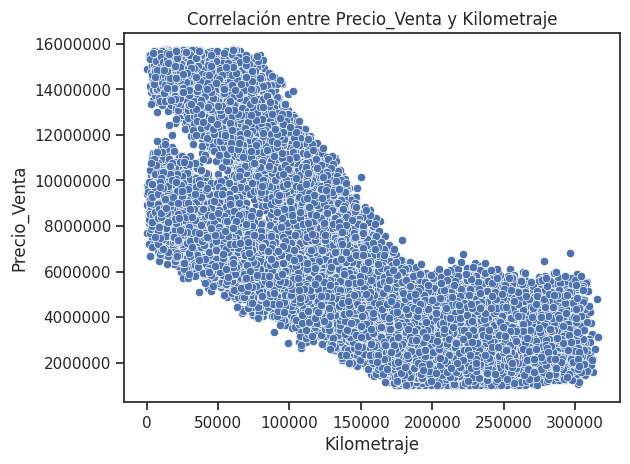

In [126]:
#Diagrama de dispersion
sb.scatterplot(
    x=df. Kilometraje,
    y=df. Precio_Venta,
    data=df)
plt.xticks(rotation=0) #rotar etiquetas del eje X
plt.title("Correlación entre Precio_Venta y Kilometraje")
plt.show()

Se observa una tendencia descendente: a mayor kilometraje, menor precio de venta, consistente con la correlación negativa (r=-0,76) calculada previamente. Esto confirma que el kilometraje es un factor relevante al momento de tasar un vehículo.


# **5. CONCLUSIONES**

In [130]:
print(f". La marca más vendida es: {df['Marca'].mode()[0]}")
print(f". La región con más ventas es: {df['Region'].mode()[0]}")
print(f". La ciudad con menos ventas es: {df['Ciudad'].value_counts().idxmin()}")
print(f". El método de pago más usado es: {df['Metodo_Pago'].mode()[0]}")
print(f". El precio de venta promedio es: ${round(df['Precio_Venta'].mean())}")
print(f". El kilometraje promedio es: {round(df['Kilometraje'].mean())} km")
print(f". La transmisión más común es: {df['Transmision'].mode()[0]}")
print(f". La antigüedad promedio de los vehículos es: {round(df['Antigüedad'].mean())} años")
print(f". El combustible menos frecuente es: {df['Combustible'].value_counts().idxmin()}")

. La marca más vendida es: Toyota
. La región con más ventas es: Metropolitana
. La ciudad con menos ventas es: Chillán
. El método de pago más usado es: credito
. El precio de venta promedio es: $5865826
. El kilometraje promedio es: 127039 km
. La transmisión más común es: Automática
. La antigüedad promedio de los vehículos es: 10 años
. El combustible menos frecuente es: Eléctrico


El análisis descriptivo permitió responder al objetivo planteado inicialmente, caracterizar el comportamiento de venta de la automotora e identificar los factores que explican el precio de los vehículos comercializados.

Algunas observaciones importantes que identifiqué fue que el año de fabricación, el kilometraje y la antigüedad resultaron ser los principales determinantes del precio, con correlaciones fuertes (|r| entre 0,70 y 0,76), mientras que la variable Precio_Venta mostró una distribución con asimetría positiva (0,89) y alta dispersión (CV=53,97%), reflejando un mercado heterogéneo donde se vinculan los vehículos económicos y los de alto valor.

A esto se suma que la transmisión automática se asocia consistentemente a vehículos más nuevos y de mayor precio, y que la demanda se concentra fuertemente en pocas marcas (Toyota, Kia, Hyundai) y en la Región Metropolitana (33,79% de las ventas).


Finalmente, estos resultados confirman que el precio de un vehículo en esta automotora no depende de un único factor aislado, sino de la combinación entre antigüedad/uso, marca y tipo de transmisión. Con esta base, la empresa puede tomar decisiones más informadas de precios, gestión de inventario y foco comercial regional.

---
---
# **DOCUMENTACIÓN**

NumPy Developers. (s. f.). NumPy documentation. NumPy. Recuperado el 22 de agosto de 2026, de https://numpy.org/devdocs/user/index.html

pandas Development Team. (s. f.). pandas documentation. pandas. Recuperado el 22 de agosto de 2026, de https://pandas.pydata.org/docs/user_guide/index.html

The Matplotlib Development Team. (s. f.). Matplotlib documentation. Matplotlib. Recuperado el 22 de agosto de 2026, de https://matplotlib.org/stable/users/index.html

Waskom, M. (s. f.). Seaborn: Statistical data visualization. Seaborn. Recuperado el 22 de agosto de 2026, de https://seaborn.pydata.org/tutorial.html

The Matplotlib Development Team. (s. f.). List of named colors. Matplotlib. Recuperado el 22 de agosto de 2026, de https://matplotlib.org/stable/gallery/color/named_colors.html